In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.units import u
from astropy.coordinates import SkyCoord
import sys
import plotfancy as pf

pf.housestyle_rcparams()

True

In [78]:
CUBE_PATH = '../../cubes/macs0159m34_COMBINED_CUBE_MED_FINAL.fits'
TITLE = 'MACS'
RADIUS_ARCSEC = .6
Z = 0.249

ra_hms = '01h59m04.03s'
dec_dms = '-34d13m31.8s'
coords = SkyCoord(ra_hms, dec_dms, frame='icrs')
RA_DEG = coords.ra.deg
DEC_DEG = coords.dec.deg

In [98]:
def generate_gaussian_profile(
    gauss_params,
    num_points: int = 500,
    width_factor: float = 4.0
) -> np.ndarray:
    sigma = gauss_params.fwhm / (2 * np.sqrt(2 * np.log(2)))

    x_min = gauss_params.lpeak - width_factor * gauss_params.fwhm / 2
    x_max = gauss_params.lpeak + width_factor * gauss_params.fwhm / 2
    x = np.linspace(x_min, x_max, num_points)

    y = gauss_params.cont + gauss_params.peak * np.exp(
        -((x - gauss_params.lpeak) ** 2) / (2 * sigma ** 2)
    )
    return np.vstack((x, y))


def analyze_galaxy_spectrum(cube_path, ra, dec, radius, z, titlename, pref):
    # 1. Load the Datacube
    print(f'Loading datacube: {cube_path}...')
    try:
        cube = Cube(cube_path)
        print(f'Successfully loaded cube. Dimensions: {cube.shape}')
    except FileNotFoundError:
        print(f'Error: Datacube not found at {cube_path}')
        print('Please ensure the path is correct and you are running this script from the project\'s root directory.')
        sys.exit(1)

    # 2. Extract the 1D Spectrum
    center = (dec, ra)  # (Dec, RA) order for MPDAF
    print(f'\nExtracting spectrum at (RA, Dec) = ({ra:.6f}, {dec:.6f}) with a {radius}\' radius aperture.')
    spec = cube.aperture(center, radius, is_sum=True)
    print('Extraction complete.')

    # 3. Plot the Extracted Spectrum
    fig1,ax1 = pf.create_plot(size=(8,2))
    ax1_cont = fig1.add_axes((1.1,0,1/4,1))
    spec.plot(ax=ax1, title=f'{titlename} at (RA={ra:.4f}, Dec={dec:.4f})', color='#ff004f')
    ax1.set_xlabel(r'Wavelength, $\lambda$, [$\AA$]')
    ax1.set_ylabel(r'Flux [$\times10^{-20}\,\mathrm{erg}/\AA\,s\,\mathrm{cm}^{-2}$]')
    fig1.canvas.manager.set_window_title('Extracted Spectrum')
    pf.fix_plot([ax1])
    fig1.savefig(f'figs/{titlename}_{pref}_spectra.png', dpi=600, bbox_inches='tight')


    # 4. Measure Emission Line Properties
    # De-redshift the spectrum to the rest frame by manually adjusting the wavelength solution
    spec_rest = spec.copy()
    spec_rest.wave.set_crval(spec_rest.wave.get_crval() / (1 + z))
    spec_rest.wave.set_step(spec_rest.wave.get_step() / (1 + z))

    # Define emission lines (rest-frame wavelengths in Angstroms)
    lines = {
        'Hbeta': 4861.33,
        'OIII_5007': 5006.84,
        'Halpha': 6562.80,
        'NII_6583': 6583.45
    }

    titles = {
        'Hbeta': r'H$\beta$',
        'OIII_5007': r'O$_{\mathrm{III-}5007}$',
        'Halpha': r'H$\alpha$',
        'NII_6583': r'N$_{\mathrm{II-}6583}$'   
    }

    line_fits = {}
    # Fit each line with a Gaussian
    for name, wavelength in lines.items():
        fit = spec_rest.gauss_fit(lmin=(wavelength - 15), lmax=(wavelength + 15), plot=False)
        line_fits[name] = fit

    # Plot the fits for visual inspection
    fig2, axes = plt.subplots(2, 2, figsize=(8, 7.5))
    fig2.canvas.manager.set_window_title('Emission Line Fits')

    for ax, name in zip(axes.ravel(), lines.keys()):
        fit = line_fits.get(name)
        if fit is not None:
            global gprofile
            gprofile = generate_gaussian_profile(fit, 500,100)
            ax.plot(gprofile[0], gprofile[1], color='k', lw=1.4)
            spec_rest.plot(ax=ax, color='#ff004f')
            ax.set_xlim([np.min(gprofile[0]), np.max(gprofile[0])])
            ax.set_title(titles[name])
            ax.set_ylabel(r'Flux [$\times10^{-20}\,\mathrm{erg}/\AA\,s\,\mathrm{cm}^{-2}$]')
            ax.set_xlabel(r'Rest Frame $\lambda$, $[\AA]$')
        else:
            ax.set_title(f'{name} (Fit Failed)')
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    pf.fix_plot(axes.flatten())
    fig2.savefig(f'figs/{titlename}_{pref}_lines.png', dpi=600, bbox_inches='tight')

    # Calculate OIII/Hbeta ratio
    oiii_fit = line_fits.get('OIII_5007')
    hbeta_fit = line_fits.get('Hbeta')

    if oiii_fit and hbeta_fit and hbeta_fit.flux > 0:
        oiii_hbeta_ratio = oiii_fit.flux / hbeta_fit.flux
        oiii_hbeta_ratio_error = oiii_hbeta_ratio*np.sqrt( (oiii_fit.err_flux/oiii_fit.flux)**2 + (hbeta_fit.err_flux/hbeta_fit.flux)**2 )
        print(f'[OIII]/Hβ = {oiii_hbeta_ratio:.3f} +/- {oiii_hbeta_ratio_error:.3f}')
        print(f'log([OIII]/Hβ) = {np.log10(oiii_hbeta_ratio):.3f}\n')
    else:
        print('[OIII]/Hβ could not be calculated.\n')

    # Calculate NII/Halpha ratio
    nii_fit = line_fits.get('NII_6583')
    halpha_fit = line_fits.get('Halpha')
    if nii_fit and halpha_fit and halpha_fit.flux > 0:
        nii_halpha_ratio = nii_fit.flux / halpha_fit.flux
        nii_halpha_ratio_error = nii_halpha_ratio*np.sqrt( (nii_fit.err_flux/nii_fit.flux)**2 + (halpha_fit.err_flux/halpha_fit.flux)**2 )
        print(f'[NII]/Hα = {nii_halpha_ratio:.3f} +/- {nii_halpha_ratio_error:.3f}')
        print(f'log([NII]/Hα) = {np.log10(nii_halpha_ratio):.3f}\n')
    else:
        print('[NII]/Hα could not be calculated.\n')

    

    return spec, line_fits

[INFO] 36 spaxels used


Loading datacube: ../../cubes/macs0159m34_COMBINED_CUBE_MED_FINAL.fits...
Successfully loaded cube. Dimensions: (3681, 314, 329)

Extracting spectrum at (RA, Dec) = (29.766792, -34.225500) with a 0.6' radius aperture.
Extraction complete.
[OIII]/Hβ = 3.569 +/- 0.709
log([OIII]/Hβ) = 0.553

[NII]/Hα = 0.049 +/- 0.029
log([NII]/Hα) = -1.307



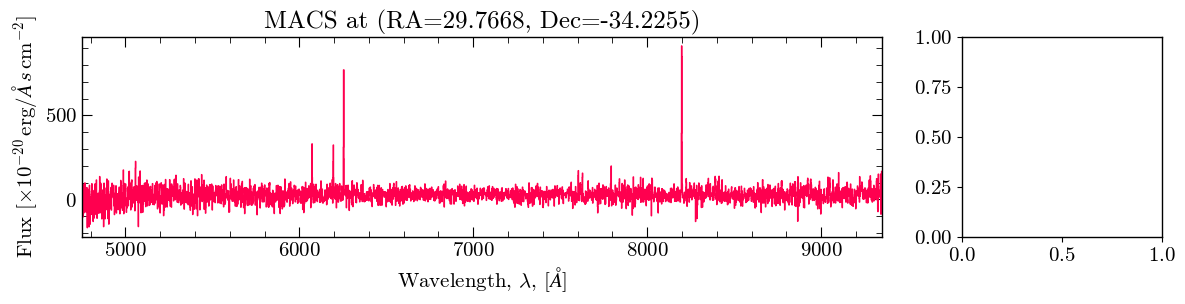

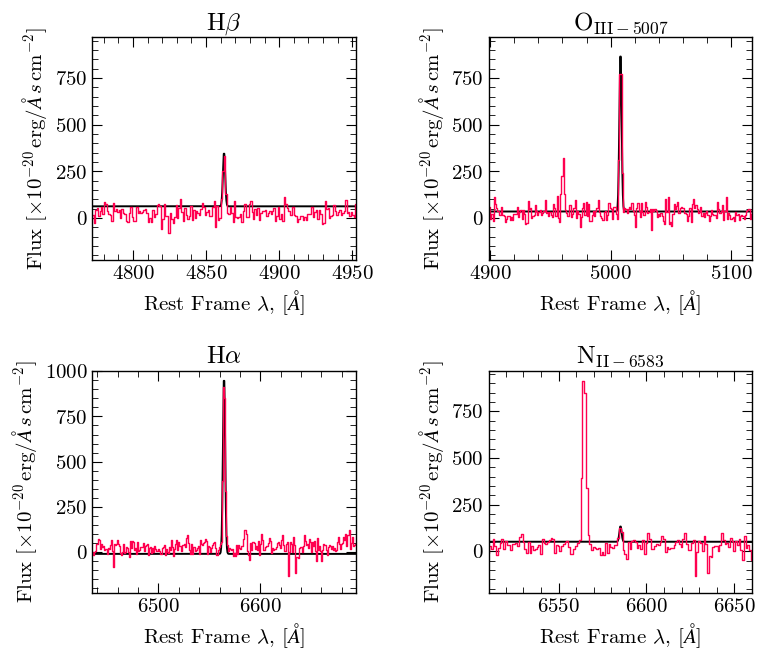

In [99]:
spec, lf1 = analyze_galaxy_spectrum(
    cube_path=CUBE_PATH,
    ra=RA_DEG,
    dec=DEC_DEG,
    radius=RADIUS_ARCSEC,
    z=Z,
    titlename=TITLE,
    pref=ra_hms.replace('.','p')+'_'+dec_dms.replace('.','p')
)